In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
titanic=sns.load_dataset("titanic")

In [4]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [6]:
#missing data
from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [7]:
#encode 
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [8]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [9]:
x=titanic[features]
y=titanic[target]

In [10]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [11]:
x_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [12]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))


accuracy: 0.770949720670391


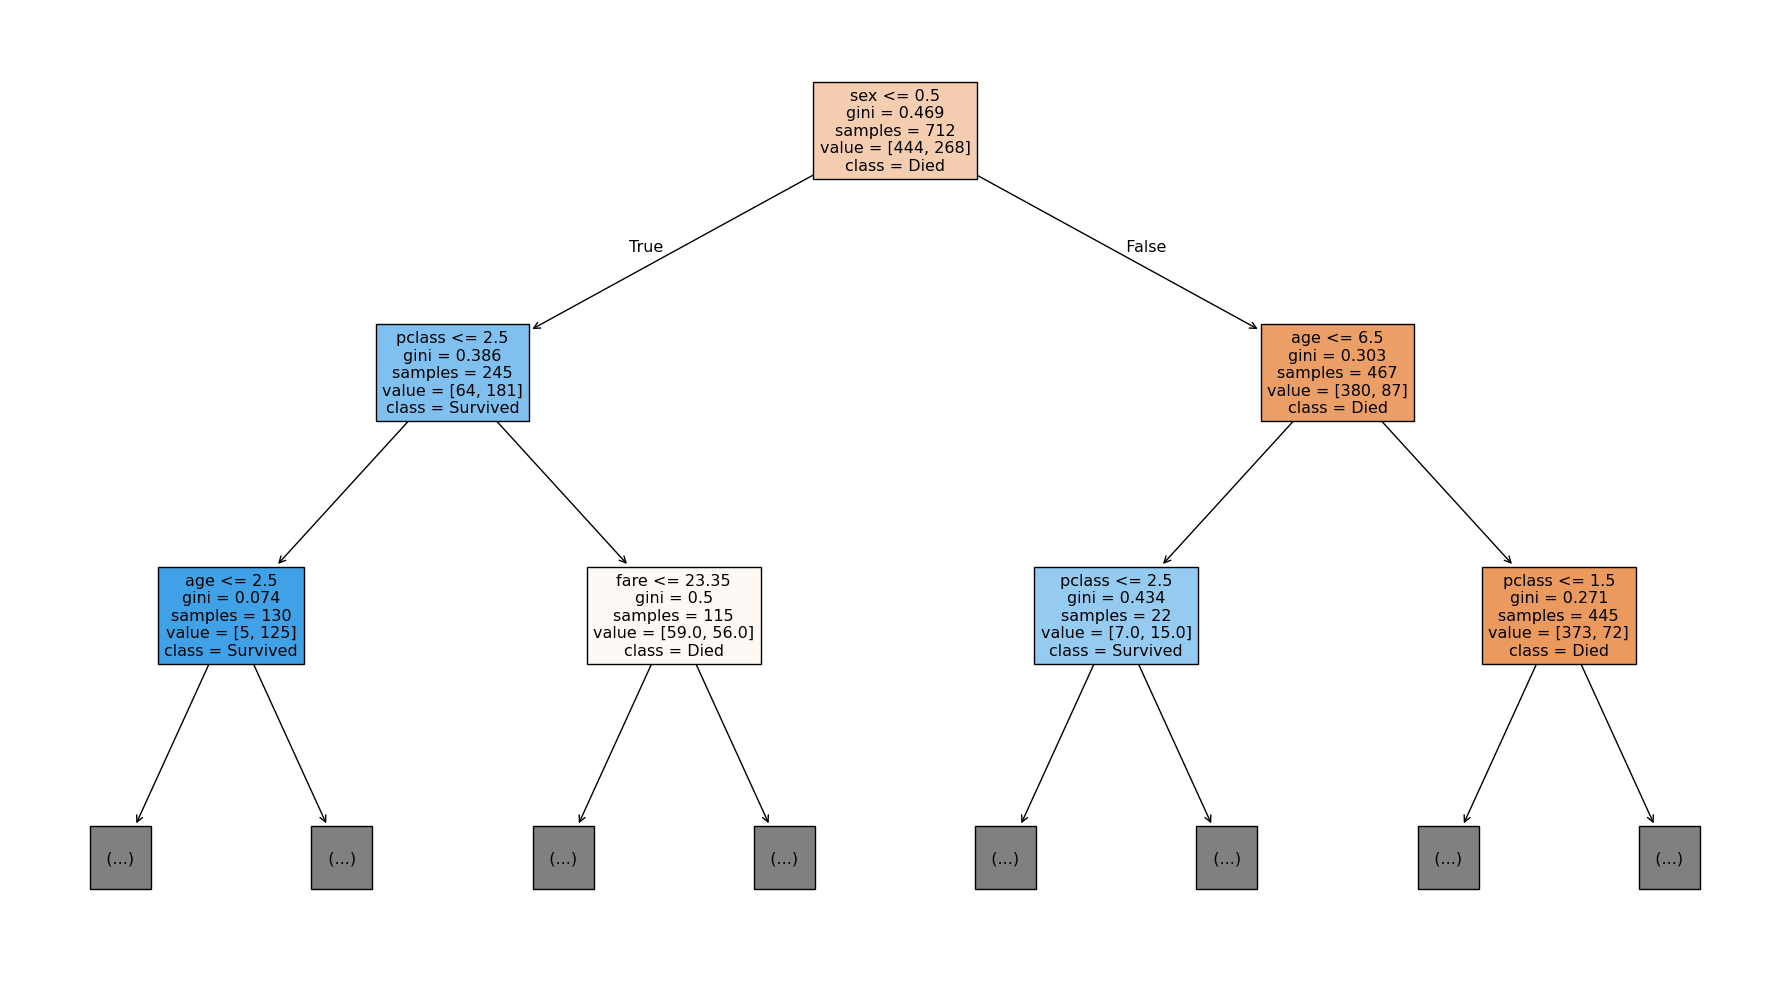

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model, 
    feature_names=x.columns, 
    class_names=["Died", "Survived"], 
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()

In [15]:
#decision tree with pre-pruning
max_depths=[2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for depth={depth},accuracy={acc}")


for depth=2,accuracy=0.7653631284916201
for depth=3,accuracy=0.7988826815642458
for depth=4,accuracy=0.7988826815642458
for depth=5,accuracy=0.7988826815642458
for depth=6,accuracy=0.8044692737430168
for depth=7,accuracy=0.7877094972067039


for depth=8,accuracy=0.7877094972067039
for depth=9,accuracy=0.7932960893854749
for depth=10,accuracy=0.7988826815642458


for sample split+5,accuracy=0.7988826815642458
for sample split+10,accuracy=0.7988826815642458


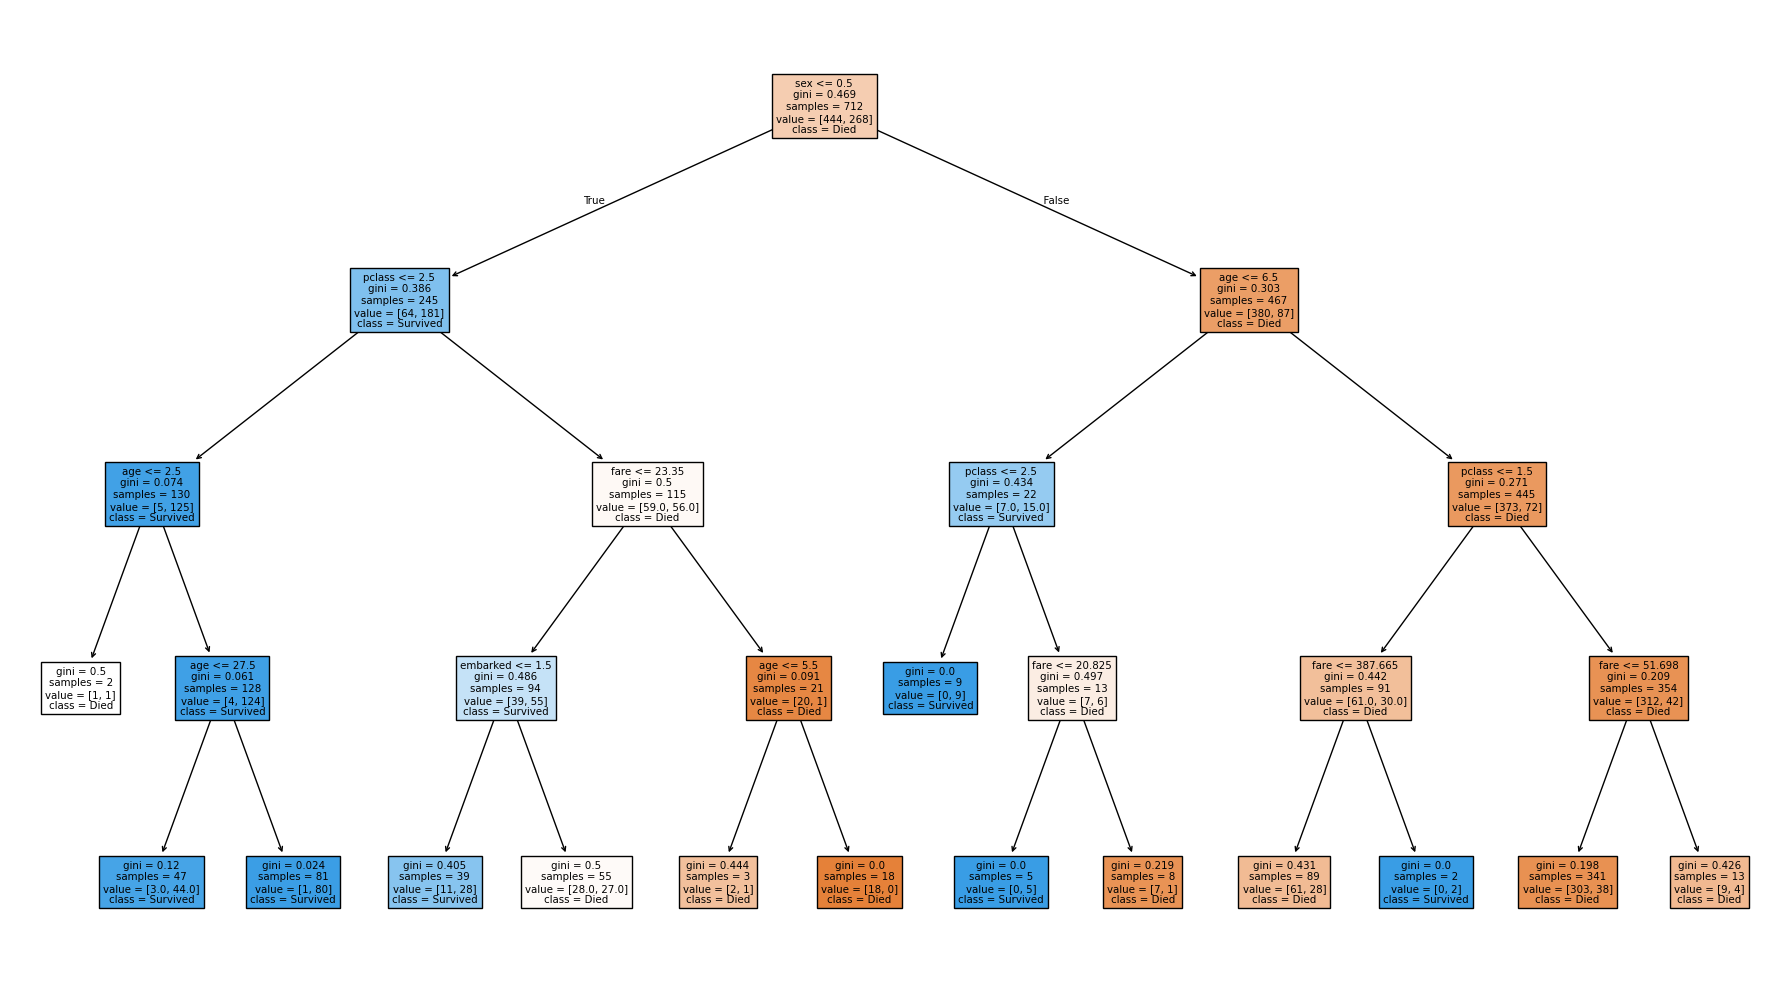

for sample split+15,accuracy=0.7988826815642458


for sample split+20,accuracy=0.7988826815642458


for sample split+25,accuracy=0.7932960893854749


for sample split+30,accuracy=0.7932960893854749


In [16]:
min_samples_splits=[5,10,15,20,25,30]
for split in min_samples_splits:
    model=DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for sample split+{split},accuracy={acc}")
    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=x.columns,
            class_names=["Died","Survived"],
            filled=True
        )
        plt.tight_layout()
        plt.show()

In [17]:
#post pruning
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [19]:
best_acc = 0
best_alpha = 0

# Loop directly through ccp_alphas
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(x_train, y_train)
    
    acc = model.score(x_test, y_test)
    if acc > best_acc:
        best_acc = acc
        best_alpha = alpha

# Train final best model using the optimal alpha
best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit(x_train, y_train)
        

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_name=x.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None
